>**Projeto Processamento de Big Data** 


>**Grupo 4**: Camila Sousa 111017 | Carolina Brunheta 110888 | Miguel Correia 110786


>**2023/24**

>**Importação e Depuração dos dados**

### Initial settings

#### Packages e imports adicionais

In [1]:
# findspark - facilita a integração do Spark com notebooks e outros ambientes de Python.
# ajuda a encontrar a instalação do Spark para que você possa usar suas funcionalidades dentro do seu código Python

# pyspark - interface do Apache Spark para Python. É uma plataforma de computação em cluster rápida e de propósito geral para processamento de big data.

import pyspark

from pyspark.sql import SparkSession
from pyspark.sql.types import *
import pyspark.sql.functions as F

import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
from pyspark.sql.types import StructType, StructField
from pyspark.sql.types import StringType, IntegerType, FloatType, TimestampType, DoubleType
from pyspark.sql.functions import col, dayofweek, hour, udf, dayofmonth, expr, month, when
import pandas as pd
import matplotlib.pyplot as plt
import math




In [3]:
# Criar Spark Session - é a entrada principal para o Spark. Permite a criação de DataFrames e a execução de consultas SQL.
# É a maneira principal de interagir com o Spark numa aplicação PySpark.

spark = SparkSession \
    .builder \
    .appName("LondonBikeShareUsage") \
    .config("spark.driver.memory", "6g")\
    .config("spark.executor.memory", "6g")\
    .config("spark.sql.shuffle.partitions", 6) \
    .config("spark.sql.repl.eagereval.enabled", True) \
    .getOrCreate()

# config("spark.sql.shuffle.partitions", 6):
# Ajustar o número de partições de shuffle é uma prática de otimização da performance do Spark.
# Como não há clusters, não é um parâmetro tão relevante.

# config("spark.sql.repl.eagereval.enabled", True):
# A seguinte configuração é útil para ambientes interativos (como notebooks) onde se deseja ver os resultados das operações
# imediatamente, facilitando o desenvolvimento e a depuração.

----------------------------------------
Exception occurred during processing of request from ('127.0.0.1', 56502)
Traceback (most recent call last):
  File "/opt/conda/envs/vscode_pyspark/lib/python3.11/socketserver.py", line 317, in _handle_request_noblock
    self.process_request(request, client_address)
  File "/opt/conda/envs/vscode_pyspark/lib/python3.11/socketserver.py", line 348, in process_request
    self.finish_request(request, client_address)
  File "/opt/conda/envs/vscode_pyspark/lib/python3.11/socketserver.py", line 361, in finish_request
    self.RequestHandlerClass(request, client_address, self)
  File "/opt/conda/envs/vscode_pyspark/lib/python3.11/socketserver.py", line 755, in __init__
    self.handle()
  File "/opt/conda/envs/vscode_pyspark/lib/python3.11/site-packages/pyspark/accumulators.py", line 295, in handle
    poll(accum_updates)
  File "/opt/conda/envs/vscode_pyspark/lib/python3.11/site-packages/pyspark/accumulators.py", line 267, in poll
    if self.rfile i

In [4]:
from IPython.core.display import HTML # importa a classe HTML do módulo IPython.core.display, que permite a exibição de HTML no notebook
display(HTML("<style>pre { white-space: pre !important; }</style>"))
#É particularmente útil quando se pretende garantir que a formatação do código ou das saídas seja exibida corretamente e não seja alterada 
# pelo navegador ou pelo ambiente do Jupyter Notebook. (exemplo: espaços em brancos ou quebras de linha)

### Collect and label data

#### Data Ingestion

In [5]:
data_dir = '../datasets'

In [7]:
%cd datasets

[Errno 2] No such file or directory: 'datasets'
/home/jovyan/code/notebooks


In [5]:
pwd

'/home/jovyan/code/notebooks'

In [6]:
ls-la ..

total 20
drwxrwxrwx 1 root   root  4096 Jun  9 14:21  ./
drwsrws--- 1 jovyan users 4096 Jun  9 14:09  ../
drwxr-xr-x 1 jovyan users 4096 May  9 14:28  Aulas%20práticas/
drwxrwxrwx 1 root   root  4096 May 23 12:12 'Aulas práticas'/
drwxrwxrwx 1 root   root  4096 May 23 12:12  Dados/
drwxrwxrwx 1 root   root  4096 May 23 12:41  datasets/
drwxrwxrwx 1 root   root  4096 Apr 15 13:09  .devcontainer/
drwxr-xr-x 1 jovyan users 4096 Jun  9 14:20  london.parquet/
drwxr-xr-x 1 jovyan users 4096 Jun  9 14:24  london_small.parquet/
drwxrwxrwx 1 root   root  4096 May  9 12:52  __MACOSX/
-rw-r--r-- 1 jovyan users  441 Apr 18 14:32  mydir.txt
drwxrwxrwx 1 root   root  4096 Jun 10 08:38  notebooks/
-rwxrwxrwx 1 root   root  4795 Apr 29 12:44  PMBD-Test_env.ipynb*
drwxr-xr-x 1 jovyan users 4096 Apr 15 13:23  teste/


#### Importação/Ler o Dataset

In [6]:
# Definir schema


schema = (StructType([
   StructField("rental_id", IntegerType(), True),
   StructField("duration", FloatType(), True),
   StructField("bike_id", FloatType(), True),
   StructField("end_rental_date_time", TimestampType(), True),
   StructField("end_station_id", FloatType(), True),
   StructField("end_station_name", StringType(), True),
   StructField("start_rental_date_time", TimestampType(), True),
   StructField("start_station_id", IntegerType(), True),
   StructField("start_station_name", StringType(), True),]))

In [7]:
file_path = "../datasets/london.csv/"
london = spark.read.csv(file_path, header="true", schema= schema, sep=',')

## Exploração e Avaliação dos dados

In [8]:
london.printSchema()

root
 |-- rental_id: integer (nullable = true)
 |-- duration: float (nullable = true)
 |-- bike_id: float (nullable = true)
 |-- end_rental_date_time: timestamp (nullable = true)
 |-- end_station_id: float (nullable = true)
 |-- end_station_name: string (nullable = true)
 |-- start_rental_date_time: timestamp (nullable = true)
 |-- start_station_id: integer (nullable = true)
 |-- start_station_name: string (nullable = true)



In [22]:
london.show()

+---------+--------+-------+--------------------+--------------+--------------------+----------------------+----------------+--------------------+
|rental_id|duration|bike_id|end_rental_date_time|end_station_id|    end_station_name|start_rental_date_time|start_station_id|  start_station_name|
+---------+--------+-------+--------------------+--------------+--------------------+----------------------+----------------+--------------------+
| 61343322|    60.0|12871.0| 2016-12-28 00:01:00|         660.0|West Kensington S...|   2016-12-28 00:00:00|             633|Vereker Road Nort...|
| 61343321|   300.0| 2837.0| 2016-12-28 00:05:00|         763.0|Mile End Park Lei...|   2016-12-28 00:00:00|             531|Twig Folly Bridge...|
| 61343323|   360.0| 1269.0| 2016-12-28 00:06:00|          99.0|Old Quebec Street...|   2016-12-28 00:00:00|             116|Little Argyll Str...|
| 61343325|  1140.0| 4208.0| 2016-12-28 00:20:00|         468.0|  Cantrell Road, Bow|   2016-12-28 00:01:00|          

In [21]:
london.show(1,vertical=True,truncate=False)  # primeira linha do dataset

-RECORD 0----------------------------------------------------------
 rental_id              | 61343322                                 
 duration               | 60.0                                     
 bike_id                | 12871.0                                  
 end_rental_date_time   | 2016-12-28 00:01:00                      
 end_station_id         | 660.0                                    
 end_station_name       | West Kensington Station, West Kensington 
 start_rental_date_time | 2016-12-28 00:00:00                      
 start_station_id       | 633                                      
 start_station_name     | Vereker Road North, West Kensington      
only showing top 1 row



In [7]:
# Número de linhas e colunas

num_rows = london.count()
num_cols = len(london.columns)

# Criar um DataFrame com o resultado
counts_df = spark.createDataFrame([Row(numero_de_linhas=num_rows, numero_de_colunas=num_cols)])

# Mostrar o DataFrame
counts_df.show()

+----------------+-----------------+
|numero_de_linhas|numero_de_colunas|
+----------------+-----------------+
|        38215560|                9|
+----------------+-----------------+



In [8]:
counts_df.write.mode("overwrite").csv("./london_counts.csv", header=True)


### Valores Duplicados

In [8]:
# Ver se tem duplicados

london = london.dropDuplicates()
london.count()

38215560

Não há duplicados

### Valores Omissos

In [9]:
# Ver valores omissos


def compute_nulls(df, cols):
    results = []
    for cl in cols:
        knulls = df.select(cl).filter(col(cl).isNull()).count()
        results.append(Row(feature=cl, count_nulls=knulls))
    return spark.createDataFrame(results)

# Exemplo de uso
london_nulls = compute_nulls(london, london.columns)
london_nulls.show()



+--------------------+-----------+
|             feature|count_nulls|
+--------------------+-----------+
|           rental_id|          0|
|            duration|      67617|
|             bike_id|         17|
|end_rental_date_time|      67617|
|      end_station_id|      68213|
|    end_station_name|      68213|
|start_rental_date...|          0|
|    start_station_id|          0|
|  start_station_name|          0|
+--------------------+-----------+



In [10]:
london_nulls.write.mode("overwrite").csv("./london_nulls.csv", header=True)

In [8]:
# Eliminar valores omissos

london = london.dropna()
london.count()

38147278

In [ ]:
with open("./total_count.txt", "w") as file:
    file.write(str(london.count()))

Foram eliminadas 68 282 instâncias

In [26]:
# Verificar que já não há valores omissos

london_nulls = compute_nulls(london, london.columns)
london_nulls.show()

+--------------------+-----------+
|             feature|count_nulls|
+--------------------+-----------+
|           rental_id|          0|
|            duration|          0|
|             bike_id|          0|
|end_rental_date_time|          0|
|      end_station_id|          0|
|    end_station_name|          0|
|start_rental_date...|          0|
|    start_station_id|          0|
|  start_station_name|          0|
+--------------------+-----------+



### Valores Únicos

In [27]:
# Ver valores únicos

print('\nValores Únicos:')
for col in london.columns:
    k = london.select(col).distinct().count()
    print(f'Coluna {col} com {k} valores únicos')


Valores Únicos:
Coluna rental_id com 38147278 valores únicos
Coluna duration com 20587 valores únicos
Coluna bike_id com 16018 valores únicos
Coluna end_rental_date_time com 1779014 valores únicos
Coluna end_station_id com 808 valores únicos
Coluna end_station_name com 840 valores únicos
Coluna start_rental_date_time com 1779959 valores únicos
Coluna start_station_id com 807 valores únicos
Coluna start_station_name com 839 valores únicos


Existem 16018 bicicletas.

In [28]:
unique_stations = set()

# Obter os valores únicos de start_station_id e end_station_id
start_station_ids = london.select("start_station_id").distinct().rdd.flatMap(lambda x: x).collect()
end_station_ids = london.select("end_station_id").distinct().rdd.flatMap(lambda x: x).collect()

unique_stations.update(start_station_ids)
unique_stations.update(end_station_ids)

num_unique_stations = len(unique_stations)
print(f"Número total de estações únicas: {num_unique_stations}")


Número total de estações únicas: 808


### Outliers

In [10]:
def describe_numeric_cols(df):
    numeric_cols = [col_name for col_name, col_type in df.dtypes if col_type in ('int', 'bigint', 'float', 'double')]
    return df.select(numeric_cols).describe().toPandas().transpose()

describe_numeric_cols(london)

,0,1,2,3,4
summary,count,mean,stddev,min,max
rental_id,38147278,8.141730076606032E7,1.1525080113827161E7,61343321,101367999
duration,38147278,1286.2330723833036,4051.253843384021,-3360.0,1984694.0
bike_id,38147278,8744.096643435476,4936.475678438068,1.0,18512.0
end_station_id,38147278,373.7964126300178,242.42063960142661,1.0,839.0
start_station_id,38147278,376.00133571784596,242.1188298169451,1,839


Duration:

A duração apresenta números negativos, o que não é suposto porque não há tempo negativo.
Além disso, o número máximo é muito elevado. 


Tentar entender o porquê destas observações:

In [8]:

negative_duration = london.filter(col("duration") < 0)
negative_duration.show()

+---------+--------+-------+--------------------+--------------+--------------------+----------------------+----------------+--------------------+
|rental_id|duration|bike_id|end_rental_date_time|end_station_id|    end_station_name|start_rental_date_time|start_station_id|  start_station_name|
+---------+--------+-------+--------------------+--------------+--------------------+----------------------+----------------+--------------------+
| 70877104|  -360.0|11391.0| 2017-10-29 01:12:00|         128.0|Emperor's Gate, S...|   2017-10-29 01:18:00|              96|Falkirk Street, H...|
| 70877106|  -780.0|14938.0| 2017-10-29 01:05:00|          37.0|Penywern Road, Ea...|   2017-10-29 01:18:00|             139|Lambeth Road, Vau...|
| 70877110|  -900.0| 4482.0| 2017-10-29 01:04:00|          37.0|Penywern Road, Ea...|   2017-10-29 01:19:00|             139|Lambeth Road, Vau...|
| 70877119|  -240.0| 8091.0| 2017-10-29 01:15:00|         737.0|Fulham Broadway, ...|   2017-10-29 01:19:00|          

In [31]:
negative_duration.count()

74

Para contornar o problema podería-se considerar a troca de valores entre as colunas start_rental_date_time e end_rental_date_time, visto que a data de começo não pode ser posterior à data do fim. Comtudo, pode adicionar complexidade ao processo de ETL (Extração, Transformação e Carga) e requer validação adicional para garantir que a troca seja a correção apropriada.

Visto que se trata apenas de 74 observações, o impacto da remoção das observações na análise global será mínimo. A remoção de dados errôneos pode, na verdade, melhorar a precisão e a confiabilidade dos resultados. 

Portanto, a eliminação dessas observações é uma solução simples e direta. 

In [9]:

#Apagar linhas com duração negativa
london = london.filter(col("duration") >= 0)

Verificar se a operação foi realizada corretamente:

In [10]:
london.filter(col("duration") < 0).count()

0

Relativamente à máxima duração, decidimos verificar se era comum viagens tão grandes:

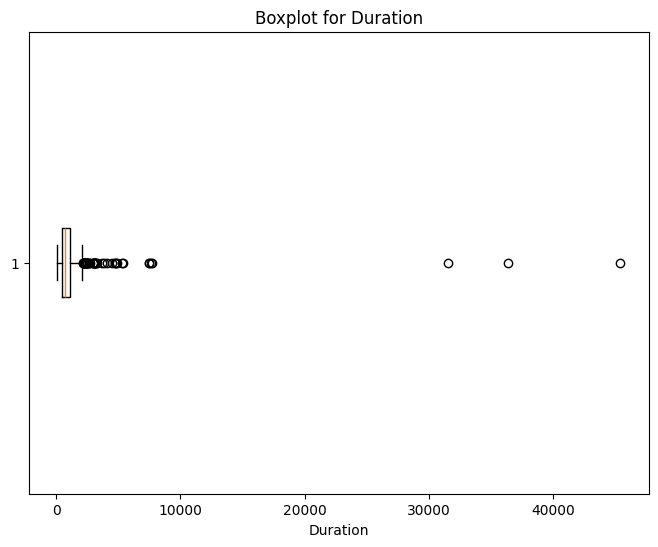

In [13]:

# Carregar os dados do DataFrame Spark para um DataFrame Pandas
london_plot = london.select("duration").limit(1000).toPandas()

# Criar o boxplot
plt.figure(figsize=(8, 6))
plt.boxplot(london_plot["duration"], vert=False)
plt.xlabel("Duration")
plt.title("Boxplot for Duration")
plt.show()

Em 1000 observações, há alguns outliers muito elevados. Tendo em conta o intervalo interquartil da variável, estas observações poderiam enviesar os resultados e por isso decidimos eliminar.

In [11]:
london = london.filter(london['duration'] <= 5000)

Decidimos, também, eliminar linhas com valor de duração igual a zero.

In [12]:
london = london.filter(col("duration") >= 60)

## Feature Engineering

### Dias da semana

Consideramos o dia da semana da viagem uma das datas do aluguer.
Os dias da semana vão ser representados de 1 a 7 (domingo a sábado)

In [13]:

# Criar uma nova coluna 'dayofweek' que contém o dia da semana do 'start_rental_date_time'
london = london.withColumn("dayofweek", dayofweek(col("start_rental_date_time")))

london.show(1,vertical=True,truncate=False)  # primeira linha do dataset

-RECORD 0----------------------------------------------------------
 rental_id              | 61343322                                 
 duration               | 60.0                                     
 bike_id                | 12871.0                                  
 end_rental_date_time   | 2016-12-28 00:01:00                      
 end_station_id         | 660.0                                    
 end_station_name       | West Kensington Station, West Kensington 
 start_rental_date_time | 2016-12-28 00:00:00                      
 start_station_id       | 633                                      
 start_station_name     | Vereker Road North, West Kensington      
 dayofweek              | 4                                        
only showing top 1 row



### Período do dia

In [14]:


def get_period_of_day(hour):
    if 6 <= hour < 12:
        return "Manhã"
    elif 12 <= hour < 17:
        return "Tarde"
    elif 17 <= hour < 21:
        return "Noite"
    else:
        return "Madrugada"

get_period_of_day_udf = udf(get_period_of_day, StringType())

# Extrair a hora das colunas de data/hora
london = london.withColumn("start_hour", hour(col("start_rental_date_time")))
london = london.withColumn("end_hour", hour(col("end_rental_date_time")))

# Aplicar a função UDF para obter o período do dia
london = london.withColumn("start_period_of_day", get_period_of_day_udf(col("start_hour")))
london = london.withColumn("end_period_of_day", get_period_of_day_udf(col("end_hour")))

# Mostrar o DataFrame com as novas colunas
# london.select("start_rental_date_time", "end_rental_date_time", "start_hour", "end_hour", "start_period_of_day", "end_period_of_day").show()
london.show(1,vertical=True,truncate=False)  # primeira linha do dataset


-RECORD 0----------------------------------------------------------
 rental_id              | 61343322                                 
 duration               | 60.0                                     
 bike_id                | 12871.0                                  
 end_rental_date_time   | 2016-12-28 00:01:00                      
 end_station_id         | 660.0                                    
 end_station_name       | West Kensington Station, West Kensington 
 start_rental_date_time | 2016-12-28 00:00:00                      
 start_station_id       | 633                                      
 start_station_name     | Vereker Road North, West Kensington      
 dayofweek              | 4                                        
 start_hour             | 0                                        
 end_hour               | 0                                        
 start_period_of_day    | Madrugada                                
 end_period_of_day      | Madrugada             

### Estações do Ano

In [15]:


london = london.withColumn("start_month", month(col("start_rental_date_time")))
london = london.withColumn("start_day_month", dayofmonth(col("start_rental_date_time")))

season_expr = """
CASE
    WHEN (start_month = 12 AND start_day_month >= 21) OR (start_month IN (1, 2)) OR (start_month = 3 AND start_day_month < 21) THEN 'winter'
    WHEN (start_month = 3 AND start_day_month >= 21) OR (start_month IN (4, 5)) OR (start_month = 6 AND start_day_month < 21) THEN 'spring'
    WHEN (start_month = 6 AND start_day_month >= 21) OR (start_month IN (7, 8)) OR (start_month = 9 AND start_day_month < 23) THEN 'summer'
    WHEN (start_month = 9 AND start_day_month >= 23) OR (start_month IN (10, 11)) OR (start_month = 12 AND start_day_month < 21) THEN 'autumn'
    ELSE 'unknown'
END 
"""
london = london.withColumn("season", expr(season_expr))
london.show(1,vertical=True,truncate=False)  # primeira linha do dataset


-RECORD 0----------------------------------------------------------
 rental_id              | 61343322                                 
 duration               | 60.0                                     
 bike_id                | 12871.0                                  
 end_rental_date_time   | 2016-12-28 00:01:00                      
 end_station_id         | 660.0                                    
 end_station_name       | West Kensington Station, West Kensington 
 start_rental_date_time | 2016-12-28 00:00:00                      
 start_station_id       | 633                                      
 start_station_name     | Vereker Road North, West Kensington      
 dayofweek              | 4                                        
 start_hour             | 0                                        
 end_hour               | 0                                        
 start_period_of_day    | Madrugada                                
 end_period_of_day      | Madrugada             

### Integração do ficheiro london_station.csv

A fim de dar uso às variáveis station_name decidimos integrar na análise as coordenadas referentes a cada estação disponíveis no ficheiro london_station, visando o enriquecimento dos dados.

In [16]:
schema2 = (StructType([
   StructField("station_id", IntegerType(), True),
   StructField("station_name", StringType(), True),
   StructField("longitude", FloatType(), True),
   StructField("latitude", FloatType(), True)]))

In [17]:
file_path2 = "../datasets/london_stations.csv/"
london_stations = spark.read.csv(file_path2, header="true", schema= schema2, sep=',')

In [18]:
london_stations.printSchema()

root
 |-- station_id: integer (nullable = true)
 |-- station_name: string (nullable = true)
 |-- longitude: float (nullable = true)
 |-- latitude: float (nullable = true)



In [20]:
london_stations.show()

+----------+--------------------+----------+---------+
|station_id|        station_name| longitude| latitude|
+----------+--------------------+----------+---------+
|         1|River Street, Cle...| -0.109971|  51.5292|
|         2|Phillimore Garden...| -0.197574|  51.4996|
|         3|Christopher Stree...|-0.0846057|  51.5213|
|         4|St. Chad's Street...| -0.120974|  51.5301|
|         5|Sedding Street, S...| -0.156876|  51.4931|
|         6|Broadcasting Hous...| -0.144229|  51.5181|
|         7|Charlbert Street,...| -0.168074|  51.5343|
|         8|Maida Vale, Maida...| -0.183486|51.529858|
|         9|New Globe Walk, B...|-0.0964408|  51.5074|
|        10|Park Street, Bank...|-0.0927542|   51.506|
|        11|Brunswick Square,...| -0.122502|   51.524|
|        12|Malet Street, Blo...| -0.130432|  51.5217|
|        13|Scala Street, Fit...|  -0.13604|  51.5199|
|        14|Belgrove Street, ...| -0.123617|  51.5299|
|        15|Great Russell Str...| -0.127854|  51.5177|
|        1

In [41]:
london_stations.show(1,vertical=True,truncate=False)  # primeira linha do dataset

-RECORD 0---------------------------------
 station_id   | 1                         
 station_name | River Street, Clerkenwell 
 longitude    | -0.109971                 
 latitude     | 51.5292                   
only showing top 1 row



In [19]:
# Número de linhas e colunas

num_rows_stations = london_stations.count()
num_cols_stations = len(london_stations.columns)

# Criar um DataFrame com o resultado
counts_stations = spark.createDataFrame([Row(numero_de_linhas=num_rows_stations, numero_de_colunas=num_cols_stations)])

# Mostrar o DataFrame
counts_stations.show()

+----------------+-----------------+
|numero_de_linhas|numero_de_colunas|
+----------------+-----------------+
|             802|                4|
+----------------+-----------------+



In [20]:
counts_stations.write.mode("overwrite").csv("./london_stations_count.csv", header=True)

Na base de dados london estistem 809 estações, contudo este dataset só contém as coordendas de 802 estações

##### Valores duplicados:

In [43]:
london_stations = london_stations.dropDuplicates()
london_stations.count()

802

Não existem valores duplicados

##### Valores omissos:

In [44]:
london_stations_nulls = compute_nulls(london_stations, london_stations.columns)
london_stations_nulls.show()

+------------+-----------+
|     feature|count_nulls|
+------------+-----------+
|  station_id|          0|
|station_name|          0|
|   longitude|          0|
|    latitude|          0|
+------------+-----------+



##### Valores Únicos

In [45]:
print('\nValores Únicos:')
for col in london_stations.columns:
    k = london_stations.select(col).distinct().count()
    print(f'Coluna {col} com {k} valores únicos')


Valores Únicos:
Coluna station_id com 802 valores únicos
Coluna station_name com 802 valores únicos
Coluna longitude com 792 valores únicos
Coluna latitude com 504 valores únicos


Os valores únicos dão a entender que está tudo certo com este dataset. 
Algumas estações podem compartilhar a mesma localização longitudinal ou latitudinal ou pode dever-se a um possível arredondamento de valores que resultou em valores duplicados.

Considerando que estas coordenadas serão apenas úteis para calcualr a distância entre as estações, não é algo que seja preciso preocupar visto que, algumas estações podem estar localizadas muito próximas umas das outras, especialmente em áreas urbanas densamente povoadas como Londres, onde a precisão de GPS pode levar a coordenadas muito semelhantes.

### Combinação dos dois datasets

Após análise, constatamos que os valores da variável station_id referem-se consistentemente ao mesmo station_name em ambos os conjuntos de dados. Com o intuito de otimizar a eficiência e a precisão da análise, decidimos cruzar as informações através do station_id em vez de strings, visto que algumas strings podem ser mais extensas e menos eficientes em comparações.

Para realizar esse cruzamento entre os conjuntos de dados, vamos adicionar as seguintes colunas ao dataset london:

- Adicionar as colunas start_latitude e start_longitude cruzando a variável station_id do conjunto de dados london_stations com a variável start_station_id do conjunto de dados london.

- Adicionar as colunas end_latitude e end_longitude cruzando a variável station_id do conjunto de dados london_stations com a variável end_station_id do conjunto de dados london.

É importante destacar que ambos os conjuntos de dados já foram previamente limpos, o que nos permite prosseguir com essa combinação sem preocupações com a qualidade dos dados. No entanto, é importante ressaltar que essa combinação resultará em valores omissos para as colunas latitude e longitude, uma vez que nem todas as estações têm suas coordenadas geográficas disponíveis.

In [19]:
london = london.join(london_stations.select("station_id", "latitude", "longitude"),
                                       london["start_station_id"] == london_stations["station_id"], "left_outer") \
                                  .drop("station_id")

# Renomear colunas para evitar conflitos
london = london\
    .withColumnRenamed("latitude", "start_latitude") \
    .withColumnRenamed("longitude", "start_longitude")

# Realizar a junção dos dados usando as colunas station_id e end_station_id
london = london.join(london_stations.select("station_id", "latitude", "longitude"),
                                                       london["end_station_id"] == london_stations["station_id"], "left_outer") \
                                                  .drop("station_id")

# Renomear colunas para evitar conflitos
london = london\
    .withColumnRenamed("latitude", "end_latitude") \
    .withColumnRenamed("longitude", "end_longitude")

# Exibir o resultado
london.show()

+---------+--------+-------+--------------------+--------------+--------------------+----------------------+----------------+--------------------+---------+----------+--------+-------------------+-----------------+-----------+---------------+------+--------------+---------------+------------+-------------+
|rental_id|duration|bike_id|end_rental_date_time|end_station_id|    end_station_name|start_rental_date_time|start_station_id|  start_station_name|dayofweek|start_hour|end_hour|start_period_of_day|end_period_of_day|start_month|start_day_month|season|start_latitude|start_longitude|end_latitude|end_longitude|
+---------+--------+-------+--------------------+--------------+--------------------+----------------------+----------------+--------------------+---------+----------+--------+-------------------+-----------------+-----------+---------------+------+--------------+---------------+------------+-------------+
| 61343322|    60.0|12871.0| 2016-12-28 00:01:00|         660.0|West Kensing

In [22]:
london.printSchema()

root
 |-- rental_id: integer (nullable = true)
 |-- duration: float (nullable = true)
 |-- bike_id: float (nullable = true)
 |-- end_rental_date_time: timestamp (nullable = true)
 |-- end_station_id: float (nullable = true)
 |-- end_station_name: string (nullable = true)
 |-- start_rental_date_time: timestamp (nullable = true)
 |-- start_station_id: integer (nullable = true)
 |-- start_station_name: string (nullable = true)
 |-- dayofweek: integer (nullable = true)
 |-- start_hour: integer (nullable = true)
 |-- end_hour: integer (nullable = true)
 |-- start_period_of_day: string (nullable = true)
 |-- end_period_of_day: string (nullable = true)
 |-- start_month: integer (nullable = true)
 |-- start_day_month: integer (nullable = true)
 |-- season: string (nullable = false)
 |-- start_latitude: float (nullable = true)
 |-- start_longitude: float (nullable = true)
 |-- end_latitude: float (nullable = true)
 |-- end_longitude: float (nullable = true)



Valores Omissos:

In [17]:

rows_with_nulls = london.filter((col("start_latitude").isNull()) |
                                (col("start_longitude").isNull()) |
                                (col("end_latitude").isNull()) |
                                (col("end_longitude").isNull()))
rows_with_nulls.show()

+---------+--------+-------+--------------------+--------------+--------------------+----------------------+----------------+--------------------+---------+----------+--------+-------------------+-----------------+-----------+---------------+------+--------------+---------------+------------+-------------+
|rental_id|duration|bike_id|end_rental_date_time|end_station_id|    end_station_name|start_rental_date_time|start_station_id|  start_station_name|dayofweek|start_hour|end_hour|start_period_of_day|end_period_of_day|start_month|start_day_month|season|start_latitude|start_longitude|end_latitude|end_longitude|
+---------+--------+-------+--------------------+--------------+--------------------+----------------------+----------------+--------------------+---------+----------+--------+-------------------+-----------------+-----------+---------------+------+--------------+---------------+------------+-------------+
| 61343838|   120.0|12321.0| 2016-12-28 07:03:00|         391.0|Clifford Str

In [49]:
rows_with_nulls.count()

9348

In [50]:
(rows_with_nulls.count()/london.count())*100

0.024505072508066383

A ausência das coordenadas de 37 estações de bicicletas criam 9348 observações incompletas no dataset. Podería ser realizadas estratégias de imputação, obtendo os valores reais das coordenadas destas estações, contudo prosseguímos à eliminação tendo em conta que representa apenas 0,02% das observações.

In [20]:
## Eliminação das linhas
london = london.dropna()

In [23]:
print("Número de linhas: ", london.count(), "      ||   Número de colunas: ", len(london.columns))

Número de linhas:  37145238       ||   Número de colunas:  21


### Variável Distance (em km)

Sem trajetórias de bicicletas em trânsito, a distância percorrida não pode ser conhecida. Mas para uma ideia aproximada pode ser obtida determinando-se a distância em linha reta entre as estações inicial e final.

In [21]:


# Definir a função UDF para calcular a distância entre duas coordenadas geográficas
@udf(FloatType())
def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calcula a distância em quilômetros entre dois pontos na superfície da Terra
    usando a fórmula de Haversine.
    """
    # Raio da Terra em quilômetros
    R = 6371.0

    # Converter graus para radianos
    lat1_rad = math.radians(lat1)
    lon1_rad = math.radians(lon1)
    lat2_rad = math.radians(lat2)
    lon2_rad = math.radians(lon2)

    # Diferença entre as latitudes e longitudes
    dlat = lat2_rad - lat1_rad
    dlon = lon2_rad - lon1_rad

    # Fórmula de Haversine
    a = math.sin(dlat / 2)**2 + math.cos(lat1_rad) * math.cos(lat2_rad) * math.sin(dlon / 2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))

    # Distância em quilômetros
    distance = R * c
    return distance

# Calcular a distância entre as estações usando a função UDF
london = london.withColumn("distance_between_stations",
                            haversine_distance(col("start_latitude"), col("start_longitude"),
                            col("end_latitude"), col("end_longitude")))


In [25]:
london.show()

+---------+--------+-------+--------------------+--------------+--------------------+----------------------+----------------+--------------------+---------+----------+--------+-------------------+-----------------+-----------+---------------+------+--------------+---------------+------------+-------------+-------------------------+
|rental_id|duration|bike_id|end_rental_date_time|end_station_id|    end_station_name|start_rental_date_time|start_station_id|  start_station_name|dayofweek|start_hour|end_hour|start_period_of_day|end_period_of_day|start_month|start_day_month|season|start_latitude|start_longitude|end_latitude|end_longitude|distance_between_stations|
+---------+--------+-------+--------------------+--------------+--------------------+----------------------+----------------+--------------------+---------+----------+--------+-------------------+-----------------+-----------+---------------+------+--------------+---------------+------------+-------------+-------------------------

In [26]:
london.printSchema()

root
 |-- rental_id: integer (nullable = true)
 |-- duration: float (nullable = true)
 |-- bike_id: float (nullable = true)
 |-- end_rental_date_time: timestamp (nullable = true)
 |-- end_station_id: float (nullable = true)
 |-- end_station_name: string (nullable = true)
 |-- start_rental_date_time: timestamp (nullable = true)
 |-- start_station_id: integer (nullable = true)
 |-- start_station_name: string (nullable = true)
 |-- dayofweek: integer (nullable = true)
 |-- start_hour: integer (nullable = true)
 |-- end_hour: integer (nullable = true)
 |-- start_period_of_day: string (nullable = true)
 |-- end_period_of_day: string (nullable = true)
 |-- start_month: integer (nullable = true)
 |-- start_day_month: integer (nullable = true)
 |-- season: string (nullable = false)
 |-- start_latitude: float (nullable = true)
 |-- start_longitude: float (nullable = true)
 |-- end_latitude: float (nullable = true)
 |-- end_longitude: float (nullable = true)
 |-- distance_between_stations: float

## Apagar colunas desnecessárias

In [22]:
# Apagar memória ocupada por variáveis que já não são mais precisas.
# import gc
# del rental_id
# del bike_id
# del end_station_name
# del start_station_name
# gc.collect()

cols_to_remove = ['rental_id', 'bike_id', 'end_station_name', 'start_station_name']

for col in cols_to_remove:
    london = london.drop(col)

In [28]:
london.printSchema()

root
 |-- duration: float (nullable = true)
 |-- end_rental_date_time: timestamp (nullable = true)
 |-- end_station_id: float (nullable = true)
 |-- start_rental_date_time: timestamp (nullable = true)
 |-- start_station_id: integer (nullable = true)
 |-- dayofweek: integer (nullable = true)
 |-- start_hour: integer (nullable = true)
 |-- end_hour: integer (nullable = true)
 |-- start_period_of_day: string (nullable = true)
 |-- end_period_of_day: string (nullable = true)
 |-- start_month: integer (nullable = true)
 |-- start_day_month: integer (nullable = true)
 |-- season: string (nullable = false)
 |-- start_latitude: float (nullable = true)
 |-- start_longitude: float (nullable = true)
 |-- end_latitude: float (nullable = true)
 |-- end_longitude: float (nullable = true)
 |-- distance_between_stations: float (nullable = true)



In [29]:
# Número de linhas e colunas

num_rows_final = london.count()
num_cols_final = len(london.columns)

# Criar um DataFrame com o resultado
count_final = spark.createDataFrame([Row(numero_de_linhas=num_rows_final, numero_de_colunas=num_cols_final)])

# Mostrar o DataFrame
count_final.show()

+----------------+-----------------+
|numero_de_linhas|numero_de_colunas|
+----------------+-----------------+
|        37145238|               18|
+----------------+-----------------+



In [30]:
count_final.write.mode("overwrite").csv("./london_count_final.csv", header=True)

## Guardar dados limpos


### Conjunto de dados menor

In [23]:
fraction = 0.3 # reduce to 30%

seed = 5
with_replacement = False
london_small = london.sample(withReplacement=with_replacement, 
                                    fraction=fraction, seed=seed)
london_small.count()

11145047

### Parquet

O DataFrame atualizado em disco garante que todas as operações pendentes sejam executadas e que apenas os dados necessários sejam armazenados.

Guardar os dataframes em parquet para usar futuramente em caso de necessidade. Depois usa-se spark.read.parquet() para carregar ficheiros

In [24]:
output_london = "london.parquet"
london.write.mode("overwrite").parquet(output_london)

In [25]:
output_london_small = "london_small.parquet"
london_small.write.mode("overwrite").parquet(output_london_small)

Verificar no diretório de execução se a tarefa foi realizada, incluindo os arquivos em formato Parquet

In [ ]:
ls -la london.parquet

total 1063896
drwxr-xr-x 1 jovyan users      4096 Jun  9 11:47 ./
drwxrwxrwx 1 root   root       4096 Jun  9 11:48 ../
-rw-r--r-- 1 jovyan users 180113618 Jun  9 11:47 part-00000-79866609-3f04-4f14-a7d4-592679c69eab-c000.snappy.parquet
-rw-r--r-- 1 jovyan users   1407148 Jun  9 11:47 .part-00000-79866609-3f04-4f14-a7d4-592679c69eab-c000.snappy.parquet.crc
-rw-r--r-- 1 jovyan users 180148098 Jun  9 11:47 part-00001-79866609-3f04-4f14-a7d4-592679c69eab-c000.snappy.parquet
-rw-r--r-- 1 jovyan users   1407416 Jun  9 11:47 .part-00001-79866609-3f04-4f14-a7d4-592679c69eab-c000.snappy.parquet.crc
-rw-r--r-- 1 jovyan users 180255325 Jun  9 11:47 part-00002-79866609-3f04-4f14-a7d4-592679c69eab-c000.snappy.parquet
-rw-r--r-- 1 jovyan users   1408256 Jun  9 11:47 .part-00002-79866609-3f04-4f14-a7d4-592679c69eab-c000.snappy.parquet.crc
-rw-r--r-- 1 jovyan users 180149696 Jun  9 11:47 part-00003-79866609-3f04-4f14-a7d4-592679c69eab-c000.snappy.parquet
-rw-r--r-- 1 jovyan users   1407428 Jun  9 11:4

In [61]:
ls -la london_small.parquet

total 324692
drwxr-xr-x 1 jovyan users     4096 Jun  9 11:50 ./
drwxrwxrwx 1 root   root      4096 Jun  9 11:48 ../
-rw-r--r-- 1 jovyan users 54986983 Jun  9 11:50 part-00000-6999f2cf-3400-463a-92ac-428165ce4915-c000.snappy.parquet
-rw-r--r-- 1 jovyan users   429596 Jun  9 11:50 .part-00000-6999f2cf-3400-463a-92ac-428165ce4915-c000.snappy.parquet.crc
-rw-r--r-- 1 jovyan users 54994396 Jun  9 11:50 part-00001-6999f2cf-3400-463a-92ac-428165ce4915-c000.snappy.parquet
-rw-r--r-- 1 jovyan users   429652 Jun  9 11:50 .part-00001-6999f2cf-3400-463a-92ac-428165ce4915-c000.snappy.parquet.crc
-rw-r--r-- 1 jovyan users 54963425 Jun  9 11:50 part-00002-6999f2cf-3400-463a-92ac-428165ce4915-c000.snappy.parquet
-rw-r--r-- 1 jovyan users   429412 Jun  9 11:50 .part-00002-6999f2cf-3400-463a-92ac-428165ce4915-c000.snappy.parquet.crc
-rw-r--r-- 1 jovyan users 55028373 Jun  9 11:50 part-00003-6999f2cf-3400-463a-92ac-428165ce4915-c000.snappy.parquet
-rw-r--r-- 1 jovyan users   429920 Jun  9 11:50 .part-000

Persistir tabelas no metastore do Hive é uma estratégia eficaz para garantir que os dados processados estejam disponíveis para análises futuras, compartilhamento e integração com outras ferramentas. Isso é especialmente útil após um processo de ETL completo, para conjuntos de dados estáveis e quando há necessidade de compartilhar os resultados com outros usuários ou aplicações. Usar saveAsTable garante que as tabelas persistam no Hive Metastore, mesmo após o reinício do programa Spark, desde que a conexão seja mantida com o mesmo metastore, oferecendo armazenamento duradouro e facilidade de acesso.


In [23]:
#Persistent tables into Hive metastore
#london.write.mode("overwrite").saveAsTable("LondonTable")